# Industrial Energy Analysis


In [1]:
import os
from pathlib import Path
from urllib.request import urlretrieve
import zipfile

os.environ["MPLCONFIGDIR"] = str(Path(".matplotlib_cache").resolve())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)


## Load data


In [2]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
csv_path = data_dir / "Steel_industry_data.csv"

if not csv_path.exists():
    zip_path = data_dir / "energy_data.zip"
    urlretrieve(
        "https://archive.ics.uci.edu/static/public/851/steel+industry+energy+consumption.zip",
        zip_path,
    )
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(data_dir)

raw = pd.read_csv(csv_path)
print(raw.shape)
raw.head()


(35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## Clean data


In [3]:
df = raw.copy()

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

df = df.rename(columns={
    "usage_kwh": "energy_kwh",
    "day_of_week": "weekday",
    "weekstatus": "week_status",
})

df["timestamp"] = pd.to_datetime(
    df.pop("date"),
    format="%d/%m/%Y %H:%M",
    errors="coerce",
)

print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = (
    df.dropna(subset=["timestamp", "energy_kwh"])
    .drop_duplicates()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print(df.shape)


Missing values: 0
Duplicate rows: 0
(35040, 11)


In [4]:
expected = pd.date_range(
    df["timestamp"].min(),
    df["timestamp"].max(),
    freq="15min",
)

checks = pd.Series({
    "missing_time_intervals": len(expected.difference(df["timestamp"])),
    "duplicate_timestamps": df["timestamp"].duplicated().sum(),
    "negative_energy_values": (df["energy_kwh"] < 0).sum(),
})

checks


missing_time_intervals    0
duplicate_timestamps      0
negative_energy_values    0
dtype: int64

## Explore


count    35040.000000
mean        27.386892
std         33.444380
min          0.000000
25%          3.200000
50%          4.570000
75%         51.237500
max        157.180000
Name: energy_kwh, dtype: float64

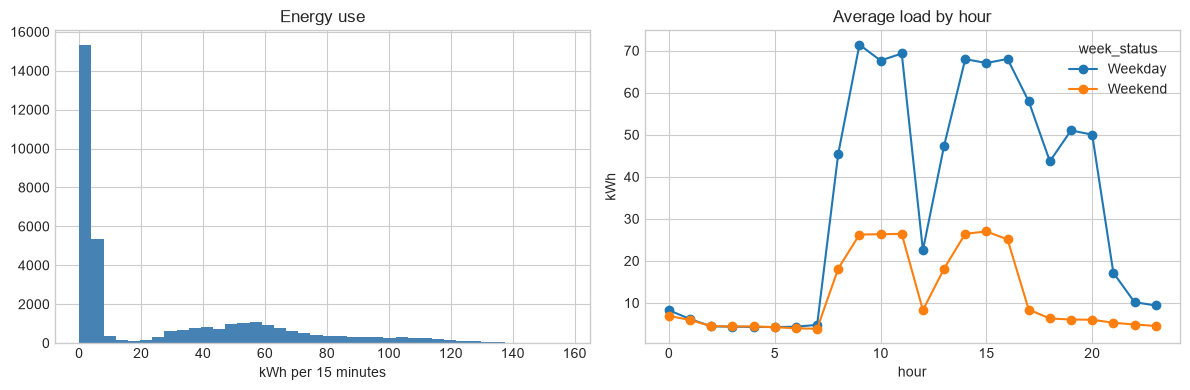

In [5]:
df["hour"] = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month
df["day_number"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_number"] >= 5).astype(int)

display(df["energy_kwh"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["energy_kwh"], bins=40, color="steelblue")
axes[0].set_title("Energy use")
axes[0].set_xlabel("kWh per 15 minutes")

hourly = df.groupby(["hour", "week_status"])["energy_kwh"].mean().unstack()
hourly.plot(ax=axes[1], marker="o")
axes[1].set_title("Average load by hour")
axes[1].set_ylabel("kWh")

plt.tight_layout()
plt.show()


In [6]:
shift = pd.cut(
    df["hour"],
    bins=[-1, 7, 15, 23],
    labels=["night", "day", "evening"],
)

df.groupby([shift, "week_status"], observed=True)["energy_kwh"].agg(
    ["count", "mean", "median", "max"]
).round(2)


count   mean  median     max
hour    week_status                              
night   Weekday       8352   5.10    3.24  105.55
        Weekend       3328   4.76    3.13  104.72
day     Weekday       8352  57.35   57.67  157.18
        Weekend       3328  22.12    4.80  133.42
evening Weekday       8352  38.43   36.90  149.65
        Weekend       3328   8.31    3.49  128.16

## Features


In [7]:
df["lag_15m"] = df["energy_kwh"].shift(1)
df["lag_1day"] = df["energy_kwh"].shift(96)

features = [
    "hour",
    "month",
    "day_number",
    "is_weekend",
    "lag_15m",
    "lag_1day",
]

model_data = df.dropna(subset=features).copy()
model_data[features + ["energy_kwh"]].head()


,hour,month,day_number,is_weekend,lag_15m,lag_1day,energy_kwh
96,0,1,1,0,3.67,3.42,4.61
97,0,1,1,0,4.61,3.17,3.20
98,0,1,1,0,3.20,4.00,3.85
99,0,1,1,0,3.85,3.24,3.28
100,1,1,1,0,3.28,3.31,3.35


## Train and test


In [8]:
split = int(len(model_data) * 0.8)

train = model_data.iloc[:split]
test = model_data.iloc[split:]

X_train = train[features]
X_test = test[features]
y_train = train["energy_kwh"]
y_test = test["energy_kwh"]

print("Train:", train["timestamp"].min(), "to", train["timestamp"].max())
print("Test: ", test["timestamp"].min(), "to", test["timestamp"].max())


Train: 2018-01-02 00:00:00 to 2018-10-20 04:30:00
Test:  2018-10-20 04:45:00 to 2018-12-31 23:45:00


In [9]:
baseline_prediction = test["lag_15m"]

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_prediction = linear_model.predict(X_test)

forest_model = RandomForestRegressor(random_state=42)
forest_model.fit(X_train, y_train)
forest_prediction = forest_model.predict(X_test)


## Results


In [10]:
def evaluate(name, actual, prediction):
    return {
        "model": name,
        "MAE": mean_absolute_error(actual, prediction),
        "RMSE": np.sqrt(mean_squared_error(actual, prediction)),
        "R2": r2_score(actual, prediction),
    }

results = pd.DataFrame([
    evaluate("Last reading", y_test, baseline_prediction),
    evaluate("Linear regression", y_test, linear_prediction),
    evaluate("Random forest", y_test, forest_prediction),
]).set_index("model")

results.round(3)


,MAE,RMSE,R2
model,,,
Last reading,5.482,12.357,0.845
Linear regression,6.595,11.759,0.860
Random forest,5.718,10.913,0.879


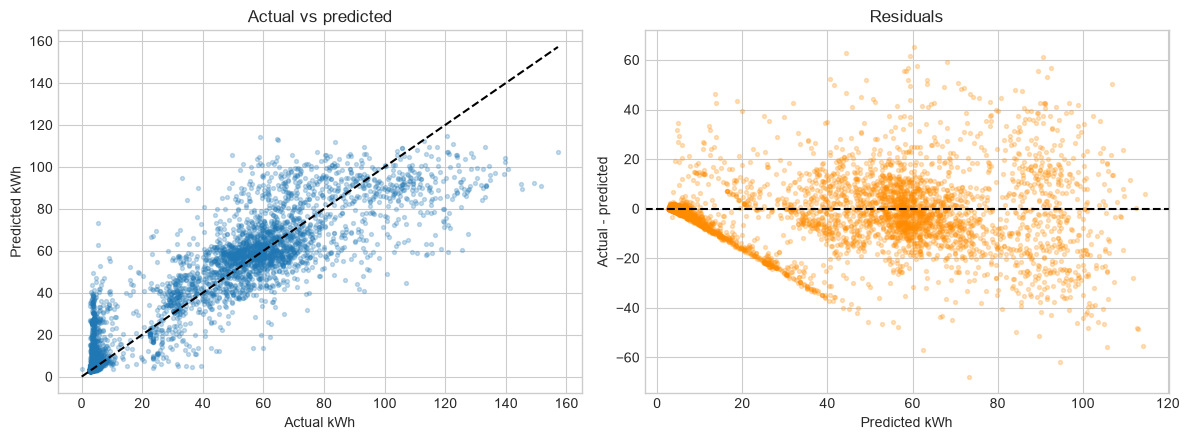

In [11]:
test_results = test[["timestamp", "energy_kwh", "hour", "week_status"]].copy()
test_results["prediction"] = forest_prediction
test_results["error"] = (
    test_results["energy_kwh"] - test_results["prediction"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(
    test_results["energy_kwh"],
    test_results["prediction"],
    s=8,
    alpha=0.25,
)
limit = test_results["energy_kwh"].max()
axes[0].plot([0, limit], [0, limit], "--", color="black")
axes[0].set_title("Actual vs predicted")
axes[0].set_xlabel("Actual kWh")
axes[0].set_ylabel("Predicted kWh")

axes[1].scatter(
    test_results["prediction"],
    test_results["error"],
    s=8,
    alpha=0.25,
    color="darkorange",
)
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Residuals")
axes[1].set_xlabel("Predicted kWh")
axes[1].set_ylabel("Actual - predicted")

plt.tight_layout()
plt.show()


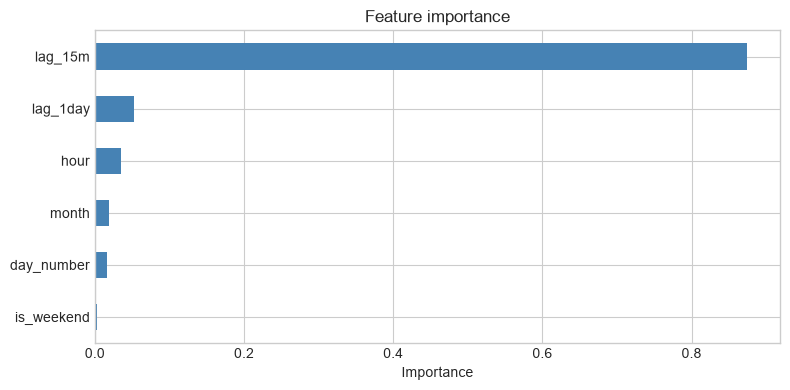

In [12]:
importance = pd.Series(
    forest_model.feature_importances_,
    index=features,
).sort_values()

importance.plot(kind="barh", figsize=(8, 4), color="steelblue")
plt.title("Feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
